# CIS 712 — AI/ML Questions 7, 8 & 9
## Exploratory Data Analysis

In this notebook I go through Questions 7, 8 and 9. Each one gives me a "dirty" dataset and asks me to explore it and get it ready for a model (Logistic Regression for the churn and admission ones, a Decision Tree for the disease one).

My plan for each dataset is the same: load it, take a look at what's there, deal with the messy or impossible values the question points me to, and then answer each sub-question with a bit of code and a chart where one is asked for. I'm keeping the code simple and sticking to plain pandas and matplotlib the whole way through.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

---
# Question 7 — Customer Churn

A telecom company wants to predict whether a customer will churn (cancel their subscription), stored in the `churned` column as Yes/No, using their usage and account details. I'll do the EDA on `customer_churn_dirty.csv` to get it ready for a Logistic Regression model.

In [2]:
churn = pd.read_csv("customer_churn_dirty.csv")
print("Shape:", churn.shape)
churn.head()

Shape: (30, 10)


,customer_id,age,gender,tenure_months,monthly_charges,contract_type,tech_support,internet_service,num_complaints,churned
0,1,34.0,Male,12,7500,Month-to-Month,No,Fiber,3,Yes
1,2,45.0,female,48,4500,One Year,Yes,DSL,0,No
2,3,NaN,Male,5,8200,Month-to-Month,No,Fiber,5,Yes
3,4,29.0,Female,60,3800,Two Year,Yes,DSL,0,No
4,5,52.0,Male,2,9000,Month-to-Month,No,Fiber,4,Yes


In [3]:
churn.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       30 non-null     int64  
 1   age               28 non-null     float64
 2   gender            30 non-null     str    
 3   tenure_months     30 non-null     int64  
 4   monthly_charges   30 non-null     int64  
 5   contract_type     30 non-null     str    
 6   tech_support      30 non-null     str    
 7   internet_service  30 non-null     str    
 8   num_complaints    30 non-null     int64  
 9   churned           30 non-null     str    
dtypes: float64(1), int64(4), str(5)
memory usage: 2.5 KB


### 7 i. How many missing or invalid values are present (check `age` and `monthly_charges` carefully)?

In [4]:
# missing values in every column
print(churn.isnull().sum())
print()

# age: how many are blank
print("age missing:", churn["age"].isnull().sum())

# monthly_charges: look for values that don't make sense
print("monthly_charges below 0:", (churn["monthly_charges"] < 0).sum())
print("monthly_charges above 20000:", (churn["monthly_charges"] > 20000).sum())
print("odd monthly_charges values:",
      churn[(churn["monthly_charges"] < 0) | (churn["monthly_charges"] > 20000)]["monthly_charges"].tolist())

customer_id         0
age                 2
gender              0
tenure_months       0
monthly_charges     0
contract_type       0
tech_support        0
internet_service    0
num_complaints      0
churned             0
dtype: int64

age missing: 2
monthly_charges below 0: 1
monthly_charges above 20000: 1
odd monthly_charges values: [-7000, 99999]


So `age` has 2 blanks (they were written as `N/A` in the file) and nothing weird beyond that. `monthly_charges` isn't technically missing anywhere, but two of the values make no sense: one is -7000, which you can't have as a charge, and another is 99999, which is obviously just a placeholder someone typed in. I'm going to treat both of those as missing before I do anything else, otherwise they'll throw the model off badly.

I'll fill the missing ages with the median age, and for the two bad `monthly_charges` values I'll blank them out and fill with the median too. I'm using the median rather than the mean on purpose here — the -7000 and 99999 would drag the mean all over the place, but the median barely notices them.

In [5]:
# fill missing age with the median age
churn["age"] = churn["age"].fillna(churn["age"].median())

# turn the impossible charges into blanks, then fill with the median
churn.loc[churn["monthly_charges"] < 0, "monthly_charges"] = None
churn.loc[churn["monthly_charges"] > 20000, "monthly_charges"] = None
churn["monthly_charges"] = churn["monthly_charges"].fillna(churn["monthly_charges"].median())

print("Any missing left?", churn[["age", "monthly_charges"]].isnull().sum().sum())
print("monthly_charges now runs from", churn["monthly_charges"].min(), "to", churn["monthly_charges"].max())

Any missing left? 0
monthly_charges now runs from 3500.0 to 9200.0


### 7 ii. What inconsistent text formatting do you notice in the `gender` column, and how would you standardize it?

In [6]:
print(churn["gender"].value_counts())

gender
Male      14
Female    13
female     2
MALE       1
Name: count, dtype: int64


The problem here is capitalisation. The same two genders are written four different ways — `Male` and `MALE`, `Female` and `female` — so the computer thinks there are four categories when there are really only two. To fix it I strip any spaces and put everything into the same case, which leaves me with just `Male` and `Female`.

In [7]:
churn["gender"] = churn["gender"].str.strip().str.capitalize()
print(churn["gender"].value_counts())

gender
Male      15
Female    15
Name: count, dtype: int64


After that it collapses down to the two categories I actually want, which is what I need before this column can be encoded for the model.

### 7 iii. What percentage of customers churned vs did not churn? Show this with a bar or pie chart.

churned
Yes    50.0
No     50.0
Name: proportion, dtype: float64


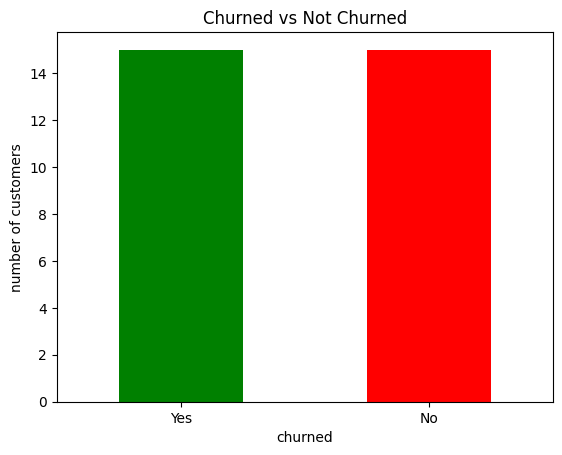

In [8]:
# percentage in each group
print(churn["churned"].value_counts(normalize=True) * 100)

# bar chart of the counts
churn["churned"].value_counts().plot(kind="bar", color=["green", "red"])
plt.title("Churned vs Not Churned")
plt.xlabel("churned")
plt.ylabel("number of customers")
plt.xticks(rotation=0)
plt.show()

It comes out to an even split — 15 customers churned and 15 didn't, so 50% each. That's actually handy, because a balanced target means the model won't be tempted to just guess one answer all the time.

### 7 iv. Does `contract_type` affect churn rate? Calculate the churn rate for each contract type and visualize it.

contract_type
Month-to-Month    100.0
One Year            0.0
Two Year            0.0
Name: churn_flag, dtype: float64


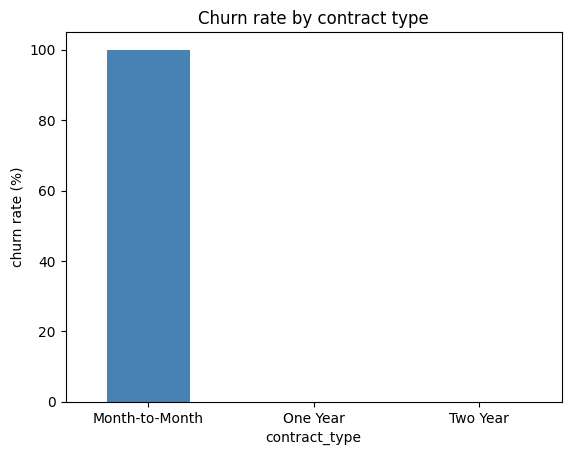

In [9]:
# make a 1/0 column so I can average it to get a rate
churn["churn_flag"] = (churn["churned"] == "Yes").astype(int)

churn_rate = churn.groupby("contract_type")["churn_flag"].mean() * 100
print(churn_rate)

churn_rate.plot(kind="bar", color="steelblue")
plt.title("Churn rate by contract type")
plt.xlabel("contract_type")
plt.ylabel("churn rate (%)")
plt.xticks(rotation=0)
plt.show()

This one's about as clear as it gets. Every single Month-to-Month customer churned (100%), and nobody on a One Year or Two Year contract did (0%). It makes sense — if you're tied into a longer contract you can't easily walk away. `contract_type` is going to be one of the strongest things the model has to work with.

### 7 v. Is there a difference in `monthly_charges` between customers who churned and those who didn't? Use a box plot to compare.

churned
No     4400.0
Yes    7800.0
Name: monthly_charges, dtype: float64


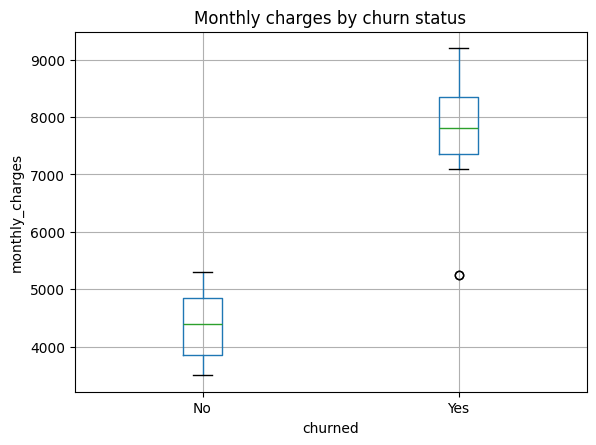

In [10]:
print(churn.groupby("churned")["monthly_charges"].median())

churn.boxplot(column="monthly_charges", by="churned")
plt.title("Monthly charges by churn status")
plt.suptitle("")   # remove the automatic title pandas adds
plt.xlabel("churned")
plt.ylabel("monthly_charges")
plt.show()

Yes, there's a real gap. The people who left were paying more — their median charge is around 7900, while the ones who stayed sit around 4400. You can see it in the box plot too: the two boxes hardly touch. So higher bills seem to go hand in hand with leaving.

### 7 vi. Do customers with more `num_complaints` churn more often? Show the relationship with a suitable plot.

Average complaints for each group:
churned
No     0.266667
Yes    3.733333
Name: num_complaints, dtype: float64

num_complaints
0      0.0
1      0.0
2    100.0
3    100.0
4    100.0
5    100.0
6    100.0
Name: churn_flag, dtype: float64


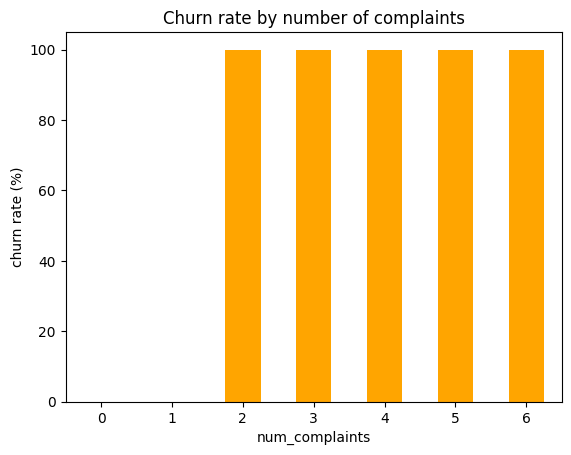

In [11]:
print("Average complaints for each group:")
print(churn.groupby("churned")["num_complaints"].mean())
print()

# churn rate for each number of complaints
complaint_rate = churn.groupby("num_complaints")["churn_flag"].mean() * 100
print(complaint_rate)

complaint_rate.plot(kind="bar", color="orange")
plt.title("Churn rate by number of complaints")
plt.xlabel("num_complaints")
plt.ylabel("churn rate (%)")
plt.xticks(rotation=0)
plt.show()

Definitely. The customers who stayed had barely any complaints (about 0.3 on average), while the ones who left averaged nearly 4. Once you look at it by complaint count, anyone with two or more complaints churned every time. So the more someone complains, the more likely they are to leave — no real surprise there, but good to see it in the numbers.

---
# Question 8 — Student Admission

Here a university admissions office wants to predict whether an applicant gets in (`admitted`, Yes/No) from their academic and personal details. I'll clean and explore `student_admission_dirty.csv` to get it ready for a Logistic Regression model.

In [12]:
adm = pd.read_csv("student_admission_dirty.csv")
print("Shape:", adm.shape)
adm.head()

Shape: (30, 8)


,student_id,gpa,sat_score,extracurriculars,recommendation_score,years_experience,state_of_origin,admitted
0,1,3.8,1450,Yes,9,0,Lagos,Yes
1,2,2.1,980,No,4,1,Kano,No
2,3,3.5,1320,Yes,8,0,Rivers,Yes
3,4,NaN,1100,No,5,0,Oyo,No
4,5,3.9,1500,Yes,10,2,Lagos,Yes


In [13]:
adm.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            30 non-null     int64  
 1   gpa                   28 non-null     float64
 2   sat_score             30 non-null     int64  
 3   extracurriculars      30 non-null     str    
 4   recommendation_score  30 non-null     int64  
 5   years_experience      30 non-null     int64  
 6   state_of_origin       30 non-null     str    
 7   admitted              30 non-null     str    
dtypes: float64(1), int64(4), str(3)
memory usage: 2.0 KB


### 8 i. Which columns have missing or invalid values (check `gpa` and `sat_score` for entry errors)? How would you handle each one, and why (mean, median, or drop)?

In [14]:
print(adm.isnull().sum())
print()

# gpa should be between 0 and 4.0
print("gpa missing:", adm["gpa"].isnull().sum())
print("gpa above 4.0:", (adm["gpa"] > 4.0).sum(), "->",
      adm[adm["gpa"] > 4.0]["gpa"].tolist())

# sat_score should be between 400 and 1600
print("sat_score below 400:", (adm["sat_score"] < 400).sum(), "->",
      adm[adm["sat_score"] < 400]["sat_score"].tolist())

student_id              0
gpa                     2
sat_score               0
extracurriculars        0
recommendation_score    0
years_experience        0
state_of_origin         0
admitted                0
dtype: int64

gpa missing: 2
gpa above 4.0: 1 -> [4.5]
sat_score below 400: 1 -> [-950]


A couple of things jump out. `gpa` has 2 missing values, plus one entry of 4.5 — and since GPA here runs on a 0 to 4.0 scale, 4.5 is impossible, so it's an entry error. My plan is to treat that 4.5 as missing and then fill all the gaps with the median GPA. I'm going for the median instead of the mean because that stray 4.5 (and errors like it) would pull the mean upward, whereas the median stays put.

`sat_score` has a -950 in it, which is obviously wrong since you can't score negative on the SAT. Same approach: blank it out and fill with the median.

I'm not dropping any rows because there are only 30 to begin with, and throwing away whole applicants over one bad cell feels wasteful. Filling the values keeps everyone in.

In [15]:
# gpa: blank the impossible value, then fill missing with the median
adm.loc[adm["gpa"] > 4.0, "gpa"] = None
adm["gpa"] = adm["gpa"].fillna(adm["gpa"].median())

# sat_score: blank the negative value, then fill with the median
adm.loc[adm["sat_score"] < 400, "sat_score"] = None
adm["sat_score"] = adm["sat_score"].fillna(adm["sat_score"].median())

print("gpa now runs from", adm["gpa"].min(), "to", adm["gpa"].max())
print("sat_score now runs from", adm["sat_score"].min(), "to", adm["sat_score"].max())

gpa now runs from 1.9 to 3.9
sat_score now runs from 890.0 to 1500.0


### 8 ii. What is the distribution of `gpa` and `sat_score` among admitted vs not-admitted students? Use histograms or box plots to compare.

          gpa  sat_score
admitted                
No        2.3     1010.0
Yes       3.6     1390.0


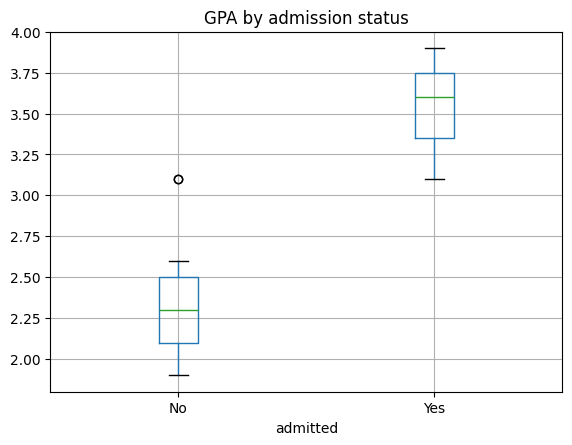

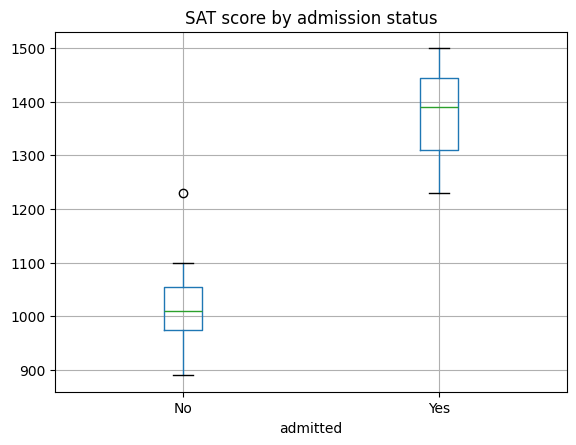

In [16]:
print(adm.groupby("admitted")[["gpa", "sat_score"]].median())

adm.boxplot(column="gpa", by="admitted")
plt.title("GPA by admission status")
plt.suptitle("")
plt.show()

adm.boxplot(column="sat_score", by="admitted")
plt.title("SAT score by admission status")
plt.suptitle("")
plt.show()

The admitted students clearly score higher on both. Their median GPA is around 3.6 and SAT around 1400, versus roughly 2.2 and 1000 for the ones who didn't get in. The boxes barely overlap, which tells me both of these columns do a good job of separating who gets in from who doesn't.

### 8 iii. Is there a clear GPA or SAT score threshold above which almost all students are admitted? Identify this visually with a scatter plot.

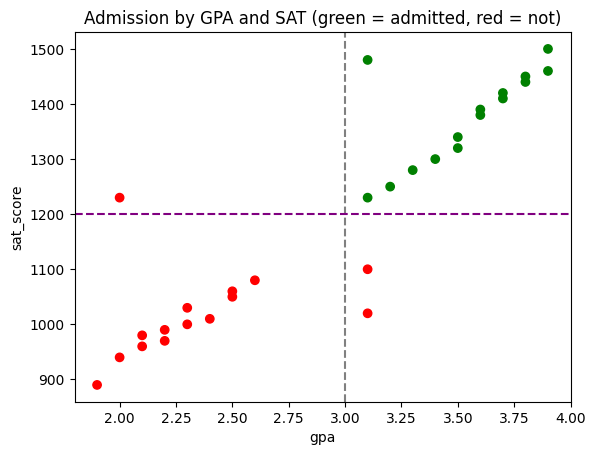

In [17]:
# colour each point by whether the student was admitted
colours = adm["admitted"].map({"Yes": "green", "No": "red"})

plt.scatter(adm["gpa"], adm["sat_score"], c=colours)
plt.axvline(3.0, color="grey", linestyle="--")
plt.axhline(1200, color="purple", linestyle="--")
plt.title("Admission by GPA and SAT (green = admitted, red = not)")
plt.xlabel("gpa")
plt.ylabel("sat_score")
plt.show()

There is, and the scatter plot shows it nicely. If I draw lines around GPA 3.0 and SAT 1200, almost everyone up and to the right of that corner is admitted (the green dots), and almost everyone below it isn't (the red dots). The two groups sit in their own clusters with barely anything in between, which is the kind of clean split a Logistic Regression will pick up on easily.

### 8 iv. Does having extracurricular activities (`extracurriculars`) increase the chance of admission? Calculate the admission rate for each group.

extracurriculars
No       0.0
Yes    100.0
Name: admit_flag, dtype: float64


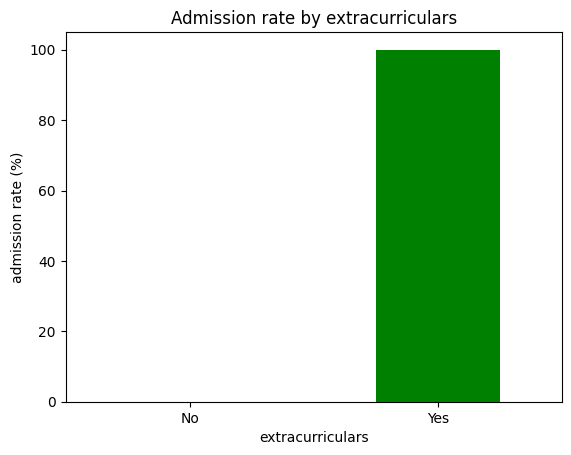

In [18]:
adm["admit_flag"] = (adm["admitted"] == "Yes").astype(int)

admit_rate = adm.groupby("extracurriculars")["admit_flag"].mean() * 100
print(admit_rate)

admit_rate.plot(kind="bar", color=["red", "green"])
plt.title("Admission rate by extracurriculars")
plt.xlabel("extracurriculars")
plt.ylabel("admission rate (%)")
plt.xticks(rotation=0)
plt.show()

In this sample it lines up perfectly — everyone with extracurriculars got in (100%) and nobody without them did (0%). That's a stronger link than you'd expect in real life, where extracurriculars would usually be just one factor among many, but for this dataset it clearly matters a lot.

### 8 v. Which state of origin has the highest admission rate in this sample? Is this likely to be a meaningful pattern or just small-sample noise? Explain your reasoning.

In [19]:
# admission rate per state, plus how many students each state has
rate = adm.groupby("state_of_origin")["admit_flag"].mean() * 100
count = adm["state_of_origin"].value_counts()

summary = pd.DataFrame({"admission_rate": rate.round(1), "students": count})
print(summary.sort_values("admission_rate", ascending=False))

                 admission_rate  students
state_of_origin                          
Abuja                     100.0         3
Enugu                     100.0         3
Rivers                    100.0         4
Lagos                      62.5         8
Kaduna                      0.0         4
Kano                        0.0         4
Oyo                         0.0         4


A few states come out at 100% — Abuja, Enugu and Rivers — but here's the catch: each of them only has three or four students. I wouldn't read anything into that. With samples that tiny, one or two decisions swing the rate straight to 0 or 100%, so it's almost certainly just noise rather than a real pattern. And there's no sensible reason a student's state should decide admission once you already know their GPA, SAT and extracurriculars. If anything, leaning on `state_of_origin` would be risky — the model could pick up a fake correlation, and it raises a fairness issue too.

---
# Question 9 — Disease Diagnosis

This time a hospital wants a tool that flags patients likely to be diagnosed with a chronic condition (`diagnosed`, Yes/No) from their health indicators. I'll clean and explore `disease_diagnosis_dirty.csv` to prepare it for a Decision Tree model.

In [20]:
dis = pd.read_csv("disease_diagnosis_dirty.csv")
print("Shape:", dis.shape)
dis.head()

Shape: (30, 10)


,patient_id,age,gender,bmi,blood_pressure,glucose_level,smoker,family_history,exercise_level,diagnosed
0,1,55.0,Male,28.5,140,160,Yes,Yes,Low,Yes
1,2,32.0,Female,22.1,110,90,No,No,High,No
2,3,NaN,Male,31.2,150,180,Yes,Yes,Low,Yes
3,4,28.0,female,21.5,105,85,No,No,High,No
4,5,60.0,Male,29.8,145,170,Yes,Yes,Low,Yes


In [21]:
dis.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   patient_id      30 non-null     int64  
 1   age             28 non-null     float64
 2   gender          30 non-null     str    
 3   bmi             30 non-null     float64
 4   blood_pressure  30 non-null     int64  
 5   glucose_level   30 non-null     int64  
 6   smoker          30 non-null     str    
 7   family_history  30 non-null     str    
 8   exercise_level  30 non-null     str    
 9   diagnosed       30 non-null     str    
dtypes: float64(2), int64(3), str(5)
memory usage: 2.5 KB


### 9 i. Identify missing values and any biologically impossible values (check `bmi` and `blood_pressure` closely — can BMI be negative? Can blood pressure realistically be 999?). How should each be handled?

In [22]:
print(dis.isnull().sum())
print()

# BMI can never be negative
print("negative bmi:", (dis["bmi"] < 0).sum(), "->", dis[dis["bmi"] < 0]["bmi"].tolist())

# a blood pressure of 999 isn't real
print("blood_pressure of 999:", (dis["blood_pressure"] == 999).sum())

patient_id        0
age               2
gender            0
bmi               0
blood_pressure    0
glucose_level     0
smoker            0
family_history    0
exercise_level    0
diagnosed         0
dtype: int64

negative bmi: 1 -> [-28.0]
blood_pressure of 999: 1


Two values here are just not physically possible. There's a BMI of -28, and BMI is weight over height squared, so it can never go negative — that's a data-entry slip. And there's a blood pressure of 999, which nobody could survive; it's clearly a placeholder somebody used for a missing reading.

The dataset doesn't show any blank cells, but these impossible numbers are really missing data in disguise, so I'll swap both of them out for blanks and fill in with the median of each column. Median again because it isn't thrown off by extreme junk values the way the mean would be.

In [23]:
# turn the impossible values into blanks, then fill with the median
dis.loc[dis["bmi"] < 0, "bmi"] = None
dis["bmi"] = dis["bmi"].fillna(dis["bmi"].median())

dis.loc[dis["blood_pressure"] == 999, "blood_pressure"] = None
dis["blood_pressure"] = dis["blood_pressure"].fillna(dis["blood_pressure"].median())

print("bmi now runs from", dis["bmi"].min(), "to", dis["bmi"].max())
print("blood_pressure now runs from", dis["blood_pressure"].min(), "to", dis["blood_pressure"].max())

bmi now runs from 19.5 to 33.0
blood_pressure now runs from 97.0 to 155.0


### 9 ii. What is the class balance of `diagnosed` (Yes vs No)? Why does this matter when training a model later?

diagnosed
Yes    15
No     15
Name: count, dtype: int64
diagnosed
Yes    50.0
No     50.0
Name: proportion, dtype: float64


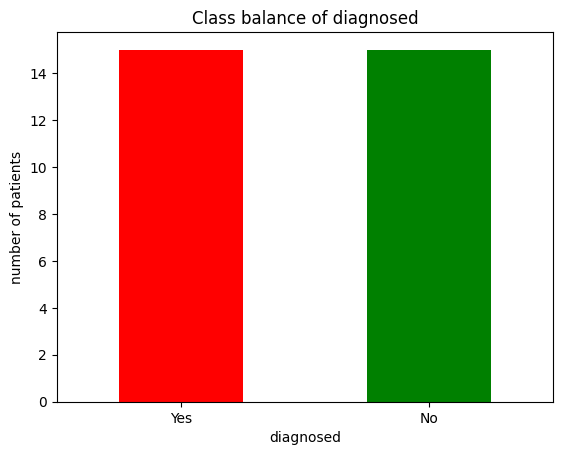

In [24]:
print(dis["diagnosed"].value_counts())
print(dis["diagnosed"].value_counts(normalize=True) * 100)

dis["diagnosed"].value_counts().plot(kind="bar", color=["red", "green"])
plt.title("Class balance of diagnosed")
plt.xlabel("diagnosed")
plt.ylabel("number of patients")
plt.xticks(rotation=0)
plt.show()

It's split evenly again, 15 and 15, so 50/50. The reason this matters is that if it were badly lopsided — say 90% not diagnosed — a model could score 90% "accuracy" by lazily saying "No" to everyone and still miss every sick patient. You'd then have to lean on precision and recall to catch that. With a balanced set like this I don't have that problem, and the tree gets a fair look at both outcomes.

### 9 iii. Compare the distribution of `glucose_level` between diagnosed and non-diagnosed patients using a box plot or histogram. What do you observe?

diagnosed
No      86.0
Yes    170.0
Name: glucose_level, dtype: float64


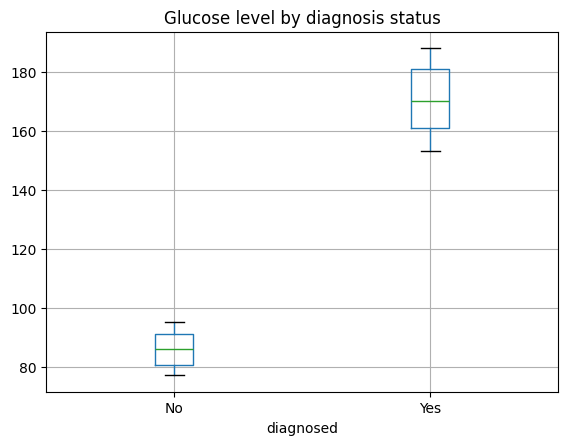

In [25]:
print(dis.groupby("diagnosed")["glucose_level"].median())

dis.boxplot(column="glucose_level", by="diagnosed")
plt.title("Glucose level by diagnosis status")
plt.suptitle("")
plt.show()

The diagnosed patients have much higher glucose. Their median is about 170 against roughly 86 for the ones who weren't diagnosed, and the two boxes sit well apart with almost no overlap. So high glucose is a strong sign of diagnosis here, which should make it a really useful split for the Decision Tree.

### 9 iv. Does `smoker` status appear to be associated with diagnosis? Calculate the diagnosis rate for smokers vs non-smokers.

smoker
No       0.0
Yes    100.0
Name: diag_flag, dtype: float64


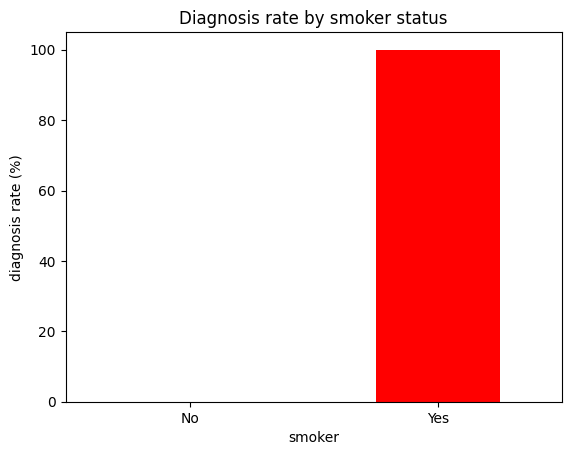

In [26]:
dis["diag_flag"] = (dis["diagnosed"] == "Yes").astype(int)

smoker_rate = dis.groupby("smoker")["diag_flag"].mean() * 100
print(smoker_rate)

smoker_rate.plot(kind="bar", color=["green", "red"])
plt.title("Diagnosis rate by smoker status")
plt.xlabel("smoker")
plt.ylabel("diagnosis rate (%)")
plt.xticks(rotation=0)
plt.show()

Very much so. Every smoker in the data was diagnosed (100%) and not a single non-smoker was (0%). That's a strong association, so smoker status is another feature the model will rely on heavily.

### 9 v. Is there a visible relationship between `exercise_level` (Low/Medium/High) and diagnosis rate? Visualize it with a bar chart.

exercise_level
Low       100.0
Medium     50.0
High        0.0
Name: diag_flag, dtype: float64


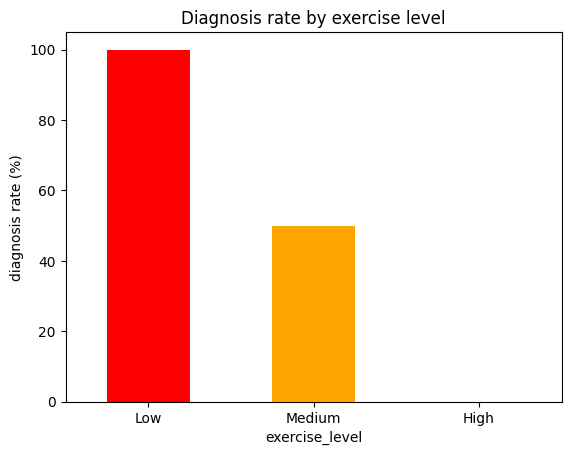

In [27]:
exercise_rate = dis.groupby("exercise_level")["diag_flag"].mean() * 100

# put the bars in a sensible order
exercise_rate = exercise_rate[["Low", "Medium", "High"]]
print(exercise_rate)

exercise_rate.plot(kind="bar", color=["red", "orange", "green"])
plt.title("Diagnosis rate by exercise level")
plt.xlabel("exercise_level")
plt.ylabel("diagnosis rate (%)")
plt.xticks(rotation=0)
plt.show()

Yes, and it goes the way you'd hope. Diagnosis rate drops steadily as people exercise more — the Low group is around 100%, Medium about 50%, and High down at 0%. Basically, the more active someone is, the less likely they are to be diagnosed, so `exercise_level` carries real signal.

### 9 vi. Patient data is sensitive. Beyond cleaning the data, what ethical consideration should you keep in mind when this kind of model is eventually deployed in a real hospital setting? (short written answer, no code required)

Cleaning the numbers is only part of the job — a tool like this touches real patients, so a few things would worry me before it went live.

The obvious one is privacy. Health records are about as sensitive as data gets, so everything has to be stored securely, kept behind proper access controls, anonymised where possible, and only used with the patient's consent and within the rules.

I'd also be careful about fairness. If the data it learned from carried any bias, the model could end up under-diagnosing or over-diagnosing certain groups of people, which in a hospital could actually widen health gaps rather than close them. It would need testing across different groups to make sure it treats everyone evenly.

Just as important, it should support the doctors, not replace them. A wrong "no" could leave a genuinely sick person untreated, and a wrong "yes" could put someone through stress and tests they didn't need, so a clinician has to have the final say every time.

And finally there's transparency and accountability — patients and staff deserve some explanation for why the model flagged someone, and there has to be a clear way to question or correct a decision when it gets one wrong. When the stakes are people's health, being cautious about all of this matters more than squeezing out a bit of extra accuracy.

---
### Wrapping up

Across the three datasets the EDA did two jobs. First it caught and fixed the messy data each question hinted at — the missing and impossible `age` and `monthly_charges`, the mixed-up `gender` text, the `gpa` and `sat_score` entry errors, the negative `bmi`, and the 999 blood-pressure placeholder. Second, it showed that the features line up sensibly with what we're trying to predict in every case. The cleaned tables are now in good shape to encode the text columns and train the models the questions ask for.